In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 1

In [3]:
df = pd.read_csv('data/startup_data.csv')

In [4]:
df.describe()


,Unnamed: 0,latitude,longitude,labels,age_first_funding_year,age_last_funding_year,age_first_milestone_year,age_last_milestone_year,relationships,funding_rounds,...,is_consulting,is_othercategory,has_VC,has_angel,has_roundA,has_roundB,has_roundC,has_roundD,avg_participants,is_top500
count,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,771.000000,771.000000,923.000000,923.000000,...,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000,923.000000
mean,572.297941,38.517442,-103.539212,0.646804,2.235630,3.931456,3.055353,4.754423,7.710726,2.310943,...,0.003250,0.322860,0.326111,0.254605,0.508126,0.392199,0.232936,0.099675,2.838586,0.809317
std,333.585431,3.741497,22.394167,0.478222,2.510449,2.967910,2.977057,3.212107,7.265776,1.390922,...,0.056949,0.467823,0.469042,0.435875,0.500205,0.488505,0.422931,0.299729,1.874601,0.393052
min,1.000000,25.752358,-122.756956,0.000000,-9.046600,-9.046600,-14.169900,-7.005500,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,283.500000,37.388869,-122.198732,0.000000,0.576700,1.669850,1.000000,2.411000,3.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000,1.000000
50%,577.000000,37.779281,-118.374037,1.000000,1.446600,3.528800,2.520500,4.476700,5.000000,2.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,2.500000,1.000000
75%,866.500000,40.730646,-77.214731,1.000000,3.575350,5.560250,4.686300,6.753400,10.000000,3.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,3.800000,1.000000
max,1153.000000,59.335232,18.057121,1.000000,21.895900,21.895900,24.684900,24.684900,63.000000,10.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,16.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 923 entries, 0 to 922
Data columns (total 49 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                923 non-null    int64  
 1   state_code                923 non-null    object 
 2   latitude                  923 non-null    float64
 3   longitude                 923 non-null    float64
 4   zip_code                  923 non-null    object 
 5   id                        923 non-null    object 
 6   city                      923 non-null    object 
 7   Unnamed: 6                430 non-null    object 
 8   name                      923 non-null    object 
 9   labels                    923 non-null    int64  
 10  founded_at                923 non-null    object 
 11  closed_at                 335 non-null    object 
 12  first_funding_at          923 non-null    object 
 13  last_funding_at           923 non-null    object 
 14  age_first_

In [6]:
drop_cols = [
    'Unnamed: 0',      # row index
    'Unnamed: 6',      # mostly null, unknown
    'id',              # identifier
    'object_id',       # identifier
    'name',            # company name
    'zip_code',        # too granular, state already encoded
    'city',            # too granular
    'state_code',      # already one-hot encoded as is_CA, is_NY etc.
    'state_code.1',    # duplicate
    'founded_at',      # raw date string - already captured in age_ columns
    'closed_at',       # leakage risk - only filled for failed companies
    'first_funding_at',# raw date - already captured in age_ columns
    'last_funding_at', # raw date - already captured in age_ columns
    'category_code',   # already one-hot encoded as is_software, is_web etc.
    'labels'
]

df = df.drop(columns=drop_cols)



In [8]:
# Make sure you're using X_test_scaled not X_train_scaled


In [7]:
print(df.isnull().sum()[df.isnull().sum() > 0])
# Add a flag column before imputing
df['has_milestone'] = df['age_first_milestone_year'].notna().astype(int)

# Then fill nulls with 0 (no milestone = 0 years to first milestone)
df['age_first_milestone_year'] = df['age_first_milestone_year'].fillna(0)
df['age_last_milestone_year']  = df['age_last_milestone_year'].fillna(0)

age_first_milestone_year    152
age_last_milestone_year     152
dtype: int64


outcome
acquired    597
closed      326
Name: count, dtype: int64

outcome
acquired    0.646804
closed      0.353196
Name: proportion, dtype: float64

<Axes: xlabel='outcome', ylabel='count'>

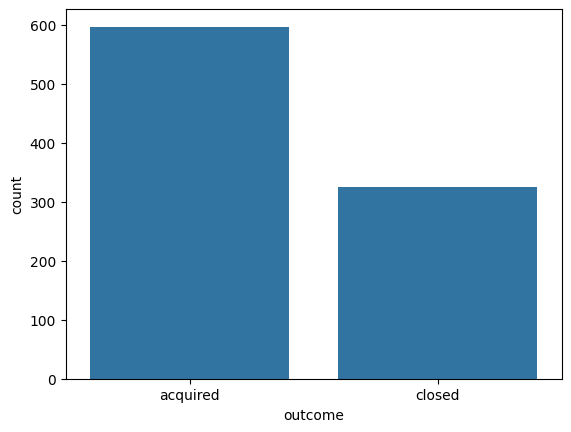

In [8]:
df = df.rename(columns={"status": "outcome"})
df.to_csv('data/startup_data_cleaned.csv', index=False)
display(df['outcome'].value_counts())
display(df['outcome'].value_counts(normalize=True))
sns.countplot(x='outcome', data=df)

In [9]:
X = df.drop(columns=['outcome'])
y = df['outcome']

In [10]:
class_names = df['outcome'].unique().tolist()  # do this BEFORE label encoding
le = LabelEncoder()
y = le.fit_transform(y)
print(le.classes_)

['acquired' 'closed']


In [11]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Step 2: split the 30% temp into 15% val and 15% test (i.e. 50/50 of temp)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
np.unique(y, return_counts=True)

(array([0, 1]), array([597, 326]))

In [14]:
np.unique(y_test, return_counts=True)
np.unique(y_train, return_counts=True)
np.unique(y_val, return_counts=True)

(array([0, 1]), array([89, 49]))

In [15]:
lr = LogisticRegression(
    max_iter=1000,              # give it enough iterations to converge
    random_state=1)
lr.fit(X_train_scaled, y_train)

svm = SVC(
    kernel='rbf',          # radial basis function - good default for tabular data
    probability=True,      # needed later for AUC calculation
    random_state=1
)
svm.fit(X_train_scaled, y_train)

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers
    max_iter=100,
    early_stopping=True,           # stops if validation loss plateaus
    random_state=1
)
mlp.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",1


In [16]:
from sklearn.metrics import classification_report, f1_score, roc_auc_score

for model in [lr, svm, mlp]:
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    print(f"Model: {model.__class__.__name__}")
    print(classification_report(y_test, y_pred, 
                                 target_names=['Closed', 'Acquired']))
    print("F1 Macro:", f1_score(y_test, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob[:, 1]))
    print("-" * 50)

Model: LogisticRegression
              precision    recall  f1-score   support

      Closed       0.78      0.81      0.79        90
    Acquired       0.62      0.57      0.60        49

    accuracy                           0.73       139
   macro avg       0.70      0.69      0.69       139
weighted avg       0.72      0.73      0.72       139

F1 Macro: 0.6946114708603145
ROC-AUC: 0.7766439909297052
--------------------------------------------------
Model: SVC
              precision    recall  f1-score   support

      Closed       0.75      0.86      0.80        90
    Acquired       0.65      0.49      0.56        49

    accuracy                           0.73       139
   macro avg       0.70      0.67      0.68       139
weighted avg       0.72      0.73      0.72       139

F1 Macro: 0.6801114341085271
ROC-AUC: 0.7242630385487528
--------------------------------------------------
Model: MLPClassifier
              precision    recall  f1-score   support

      Closed     

In [12]:
# K-Means time
inertias = []
silhouettes = []
K_range = range(2, 30)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=1, n_init=10)
    km.fit(X_train_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_train_scaled, km.labels_))


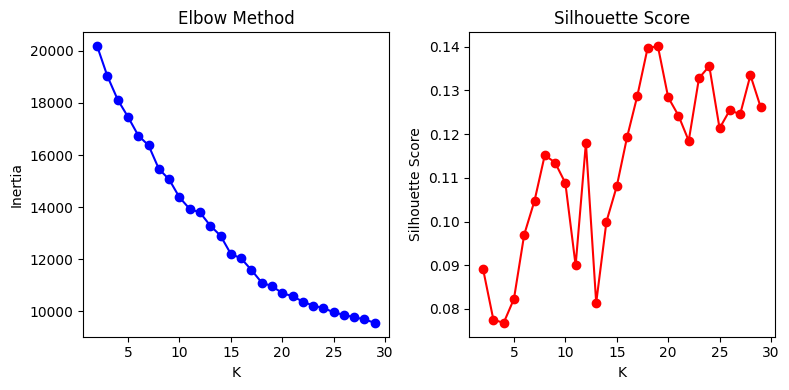

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('K')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')

ax2.plot(K_range, silhouettes, 'ro-')
ax2.set_xlabel('K')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score')

plt.tight_layout()
plt.show()

In [14]:
# Fit final K-Means on training data only
km_final = KMeans(n_clusters=6, random_state=1, n_init=10)
km_final.fit(X_train_scaled)

# Get cluster labels for all three splits
train_clusters = km_final.predict(X_train_scaled)
val_clusters   = km_final.predict(X_val_scaled)
test_clusters  = km_final.predict(X_test_scaled)

In [15]:
# Reshape cluster labels and concatenate to scaled feature matrices
def add_cluster_feature(X_scaled, clusters, n_clusters=6):
    # One-hot encode the cluster labels
    cluster_ohe = np.zeros((len(clusters), n_clusters))
    for i, c in enumerate(clusters):
        cluster_ohe[i, c] = 1
    return np.hstack([X_scaled, cluster_ohe])

X_train_hybrid = add_cluster_feature(X_train_scaled, train_clusters)
X_val_hybrid   = add_cluster_feature(X_val_scaled,   val_clusters)
X_test_hybrid  = add_cluster_feature(X_test_scaled,  test_clusters)

print(X_train_hybrid.shape)  # should be (70000, original_features + 6)

(646, 40)


In [16]:
# First build your hybrid matrices as before
train_clusters = km_final.predict(X_train_scaled)
test_clusters  = km_final.predict(X_test_scaled)

X_train_hybrid = add_cluster_feature(X_train_scaled, train_clusters)
X_test_hybrid  = add_cluster_feature(X_test_scaled,  test_clusters)

# Train NEW models on hybrid data — don't reuse the baseline models
lr_hybrid  = LogisticRegression(max_iter=1000, random_state=1)
svm_hybrid = SVC(kernel='rbf', probability=True, random_state=1)
mlp_hybrid = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                            early_stopping=True, random_state=1)

lr_hybrid.fit(X_train_hybrid,  y_train)
svm_hybrid.fit(X_train_hybrid, y_train)
mlp_hybrid.fit(X_train_hybrid, y_train)

# Evaluate on test hybrid
for name, model in [('LR + KMeans',  lr_hybrid),
                     ('SVM + KMeans', svm_hybrid),
                     ('MLP + KMeans', mlp_hybrid)]:
    y_pred = model.predict(X_test_hybrid)
    y_prob = model.predict_proba(X_test_hybrid)

    print(f"Model: {name}")
    print(classification_report(y_test, y_pred,
                                 target_names=['Closed', 'Acquired']))
    print("F1 Macro:", f1_score(y_test, y_pred, average='macro'))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob[:, 1]))
    print("-" * 50)

Model: LR + KMeans
              precision    recall  f1-score   support

      Closed       0.77      0.81      0.79        90
    Acquired       0.61      0.55      0.58        49

    accuracy                           0.72       139
   macro avg       0.69      0.68      0.68       139
weighted avg       0.71      0.72      0.72       139

F1 Macro: 0.6849171752397559
ROC-AUC: 0.7712018140589569
--------------------------------------------------
Model: SVM + KMeans
              precision    recall  f1-score   support

      Closed       0.75      0.84      0.80        90
    Acquired       0.63      0.49      0.55        49

    accuracy                           0.72       139
   macro avg       0.69      0.67      0.67       139
weighted avg       0.71      0.72      0.71       139

F1 Macro: 0.6737678281278209
ROC-AUC: 0.7257369614512472
--------------------------------------------------
Model: MLP + KMeans
              precision    recall  f1-score   support

      Closed    

In [17]:
unique, counts = np.unique(train_clusters, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} samples ({count/len(train_clusters)*100:.1f}%)")

Cluster 0: 63 samples (9.8%)
Cluster 1: 139 samples (21.5%)
Cluster 2: 68 samples (10.5%)
Cluster 3: 94 samples (14.6%)
Cluster 4: 94 samples (14.6%)
Cluster 5: 188 samples (29.1%)


In [21]:
# Get feature names after OHE
feature_names = X_train.columns.tolist()

# Inverse transform centroids to original scale
centroids_original = scaler.inverse_transform(km_final.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_names)
print(centroids_df.round(2))

# Statistical testing: ANOVA across clusters for each feature
from scipy import stats

cluster_labels = km_final.predict(X_train_scaled)

print("\n--- ANOVA: Features with statistically significant differences across clusters ---")
print(f"{'Feature':<35} {'F-stat':>10} {'p-value':>12}")
print("-" * 60)

results = []
for feature in feature_names:
    groups = [X_train[feature].values[cluster_labels == k] for k in range(km_final.n_clusters)]
    f_stat, p_val = stats.f_oneway(*groups)
    results.append((feature, f_stat, p_val))

# Sort by F-statistic descending and print
results.sort(key=lambda x: x[1], reverse=True)
for feature, f_stat, p_val in results:
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{feature:<35} {f_stat:>10.2f} {p_val:>12.4f}  {sig}")

   latitude  longitude  age_first_funding_year  age_last_funding_year  \
0     42.70     -69.83                    2.51                   5.13   
1     36.73    -115.43                    3.18                   6.58   
2     40.68     -75.08                    1.31                   2.53   
3     41.57     -93.32                    2.18                   3.24   
4     37.48    -104.85                    3.69                   4.94   
5     36.63    -118.13                    1.36                   2.18   

   age_first_milestone_year  age_last_milestone_year  relationships  \
0                      3.41                     4.63           7.94   
1                      5.29                     7.53          12.68   
2                      1.90                     3.38           7.94   
3                      2.50                     3.88           4.78   
4                      0.04                     0.04           3.24   
5                      1.91                     3.47          

In [19]:
# Add cluster labels back to training dataframe
X_train_copy = X_train.copy()
X_train_copy['cluster'] = train_clusters
X_train_copy['outcome'] = y_train

# Outcome distribution per cluster
outcome_dist = X_train_copy.groupby('cluster')['outcome'].value_counts(normalize=True).unstack()
outcome_dist.columns = ['Positive', 'Negative']  # adjust if order differs
print(outcome_dist.round(3))

         Positive  Negative
cluster                    
0           0.794     0.206
1           0.813     0.187
2           0.691     0.309
3           0.564     0.436
4           0.255     0.745
5           0.697     0.303


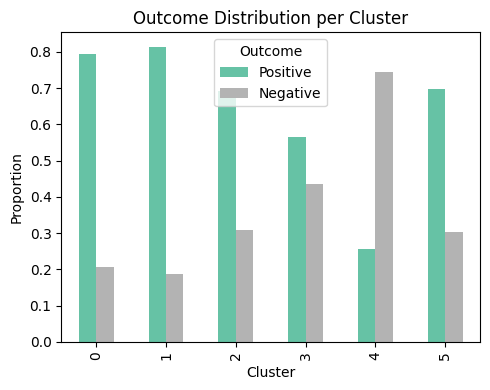

In [25]:
outcome_dist.plot(kind='bar', figsize=(5, 4), colormap='Set2')
plt.title('Outcome Distribution per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Outcome')
plt.tight_layout()
plt.show()